In [ ]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Check data                              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# Path relative to the root directory
file_path = "../../data/merged/merged_set.csv"

data = pd.read_csv(file_path)
data.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01 00:00:00,2025-01-01 00:15:00,758.0,2.93,1.703108e+10,1.703108e+10,8.0,8.0,...,0.0,0.0,0.0,985.9019,100.0,12.976239,21.575987,0.0,0.0,0.0
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01 00:00:00,2025-01-01 00:15:00,1233.0,13.66,1.703198e+10,1.703106e+10,76.0,6.0,...,0.0,0.0,0.0,985.9019,100.0,12.976239,21.575987,0.0,0.0,0.0
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01 00:00:00,2025-01-01 00:15:00,985.0,3.22,1.703108e+10,1.703107e+10,8.0,7.0,...,0.0,0.0,0.0,985.9019,100.0,12.976239,21.575987,0.0,0.0,0.0
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01 00:00:00,2025-01-01 00:15:00,652.0,3.24,1.703122e+10,1.703107e+10,22.0,7.0,...,0.0,0.0,0.0,985.9019,100.0,12.976239,21.575987,0.0,0.0,0.0
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01 00:00:00,2025-01-01 00:15:00,803.0,6.09,1.703108e+10,1.703183e+10,8.0,3.0,...,0.0,0.0,0.0,985.9019,100.0,12.976239,21.575987,0.0,0.0,0.0


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5637179 entries, 0 to 5637178
Data columns (total 48 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   trip_id                       str    
 1   taxi_id                       str    
 2   trip_start_timestamp          str    
 3   trip_end_timestamp            str    
 4   trip_seconds                  float64
 5   trip_miles                    float64
 6   pickup_census_tract           float64
 7   dropoff_census_tract          float64
 8   pickup_community_area         float64
 9   dropoff_community_area        float64
 10  fare                          float64
 11  tips                          float64
 12  tolls                         float64
 13  extras                        float64
 14  trip_total                    float64
 15  payment_type                  str    
 16  company                       str    
 17  pickup_centroid_latitude      float64
 18  pickup_centroid_longitude     flo

In [6]:
pd.DataFrame(data.dtypes, columns=['Data Type'])

,Data Type
trip_id,str
taxi_id,str
trip_start_timestamp,str
trip_end_timestamp,str
trip_seconds,float64
trip_miles,float64
pickup_census_tract,float64
dropoff_census_tract,float64
pickup_community_area,float64
dropoff_community_area,float64


In [7]:
print("Step 1: Extracting individual days from the timestamps...")
# Convert the timestamp string to a temporary datetime column to safely pull the day integer (1-31)
data['start_day'] = pd.to_datetime(data['trip_start_timestamp']).dt.day

print("Step 2: Collapsing 5.5M rows into a true 8,760-row hourly timeline...")
# Adding 'start_day' to the groupby keeps every calendar date completely separate
hourly_city_summary = data.groupby(['start_year', 'start_month', 'start_day', 'start_hour']).agg(
    total_trips=('trip_id', 'count'),
    temperature_2m=('temperature_2m', 'mean'),
    precipitation=('precipitation', 'mean'),
    apparent_temperature=('apparent_temperature', 'mean'),
    wind_speed_10m=('wind_speed_10m', 'mean'),
    sunshine_duration=('sunshine_duration', 'mean'),
    is_day=('is_day', 'mean')
).reset_index()

print("Step 3: Sorting sequentially from January 1st to December 31st...")
hourly_city_summary = hourly_city_summary.sort_values(
    by=['start_year', 'start_month', 'start_day', 'start_hour']
).reset_index(drop=True)

print(f"\nExecution Complete! New dataframe 'hourly_city_summary' created with {len(hourly_city_summary)} rows.")
print("Columns available: 'start_year', 'start_month', 'start_day', 'start_hour', 'total_trips', plus weather metrics.")

# Display the first few rows to confirm the date continuity
hourly_city_summary.head(10)

Step 1: Extracting individual days from the timestamps...
Step 2: Collapsing 5.5M rows into a true 8,760-row hourly timeline...
Step 3: Sorting sequentially from January 1st to December 31st...

Execution Complete! New dataframe 'hourly_city_summary' created with 8759 rows.
Columns available: 'start_year', 'start_month', 'start_day', 'start_hour', 'total_trips', plus weather metrics.


,start_year,start_month,start_day,start_hour,total_trips,temperature_2m,precipitation,apparent_temperature,wind_speed_10m,sunshine_duration,is_day
0,2025,1,1,0,318,0.75,0.0,-3.466830,12.976239,0.0000,0.0
1,2025,1,1,1,468,0.65,0.0,-3.722961,14.192631,0.0000,0.0
2,2025,1,1,2,355,0.20,0.1,-4.808792,17.288435,0.0000,0.0
3,2025,1,1,3,137,-0.25,0.0,-5.260139,16.557064,0.0000,0.0
4,2025,1,1,4,78,-0.50,0.0,-5.667282,16.697365,0.0000,0.0
5,2025,1,1,5,67,-0.65,0.0,-5.830750,16.595179,0.0000,0.0
6,2025,1,1,6,113,-0.95,0.0,-5.949335,15.584300,0.0000,0.0
7,2025,1,1,7,142,-0.95,0.0,-7.111548,21.259060,0.0000,0.0
8,2025,1,1,8,152,-1.70,0.0,-7.528542,19.493261,384.1223,1.0
9,2025,1,1,9,201,-1.90,0.0,-8.114071,22.169980,3600.0000,1.0


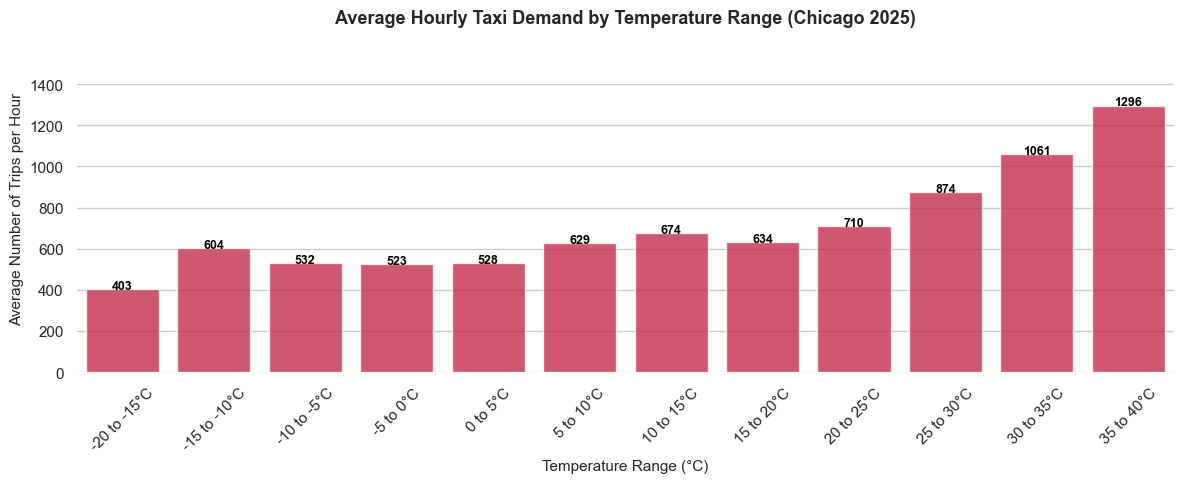

In [8]:
# 1. Create temperature buckets (5-degree increments) directly on the hourly summary
hourly_city_summary['temp_bucket'] = pd.cut(
    hourly_city_summary['temperature_2m'], 
    bins=range(-20, 41, 5),
    labels=[f"{i} to {i+5}°C" for i in range(-20, 40, 5)]
)

# 2. Directly average the true hourly totals by their temperature buckets
# Since hourly_city_summary treats every hour equally, this completely removes the grouping bias!
temp_demand = hourly_city_summary.groupby('temp_bucket', observed=False)['total_trips'].mean().reset_index()

# 3. Plot the distribution
plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=temp_demand, x='temp_bucket', y='total_trips', color='crimson', alpha=0.8)

# Add value labels on top of each bar for a cleaner, presentation-ready report
for p in ax.patches:
    if p.get_height() > 0: # Avoid labeling empty/unused temperature ranges
        ax.annotate(f"{p.get_height():.0f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height() + 15), 
                    ha='center', va='center', fontsize=9, color='black', weight='semibold')

plt.title('Average Hourly Taxi Demand by Temperature Range (Chicago 2025)', fontsize=13, pad=15, weight='bold')
plt.xlabel('Temperature Range (°C)', fontsize=11)
plt.ylabel('Average Number of Trips per Hour', fontsize=11)
plt.xticks(rotation=45)

# Give the y-axis a bit of breathing room above the tallest bar
plt.ylim(0, temp_demand['total_trips'].max() + 300)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

/var/folders/gs/gk7qm_b92t308pxzdf4h3y0r0000gn/T/ipykernel_2084/3270401240.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=precip_data, x='precip_bucket', y='total_trips', palette='Blues', ax=axes[1])
/var/folders/gs/gk7qm_b92t308pxzdf4h3y0r0000gn/T/ipykernel_2084/3270401240.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=wind_data, x='wind_bucket', y='total_trips', palette='Purples', ax=axes[2])
/var/folders/gs/gk7qm_b92t308pxzdf4h3y0r0000gn/T/ipykernel_2084/3270401240.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot

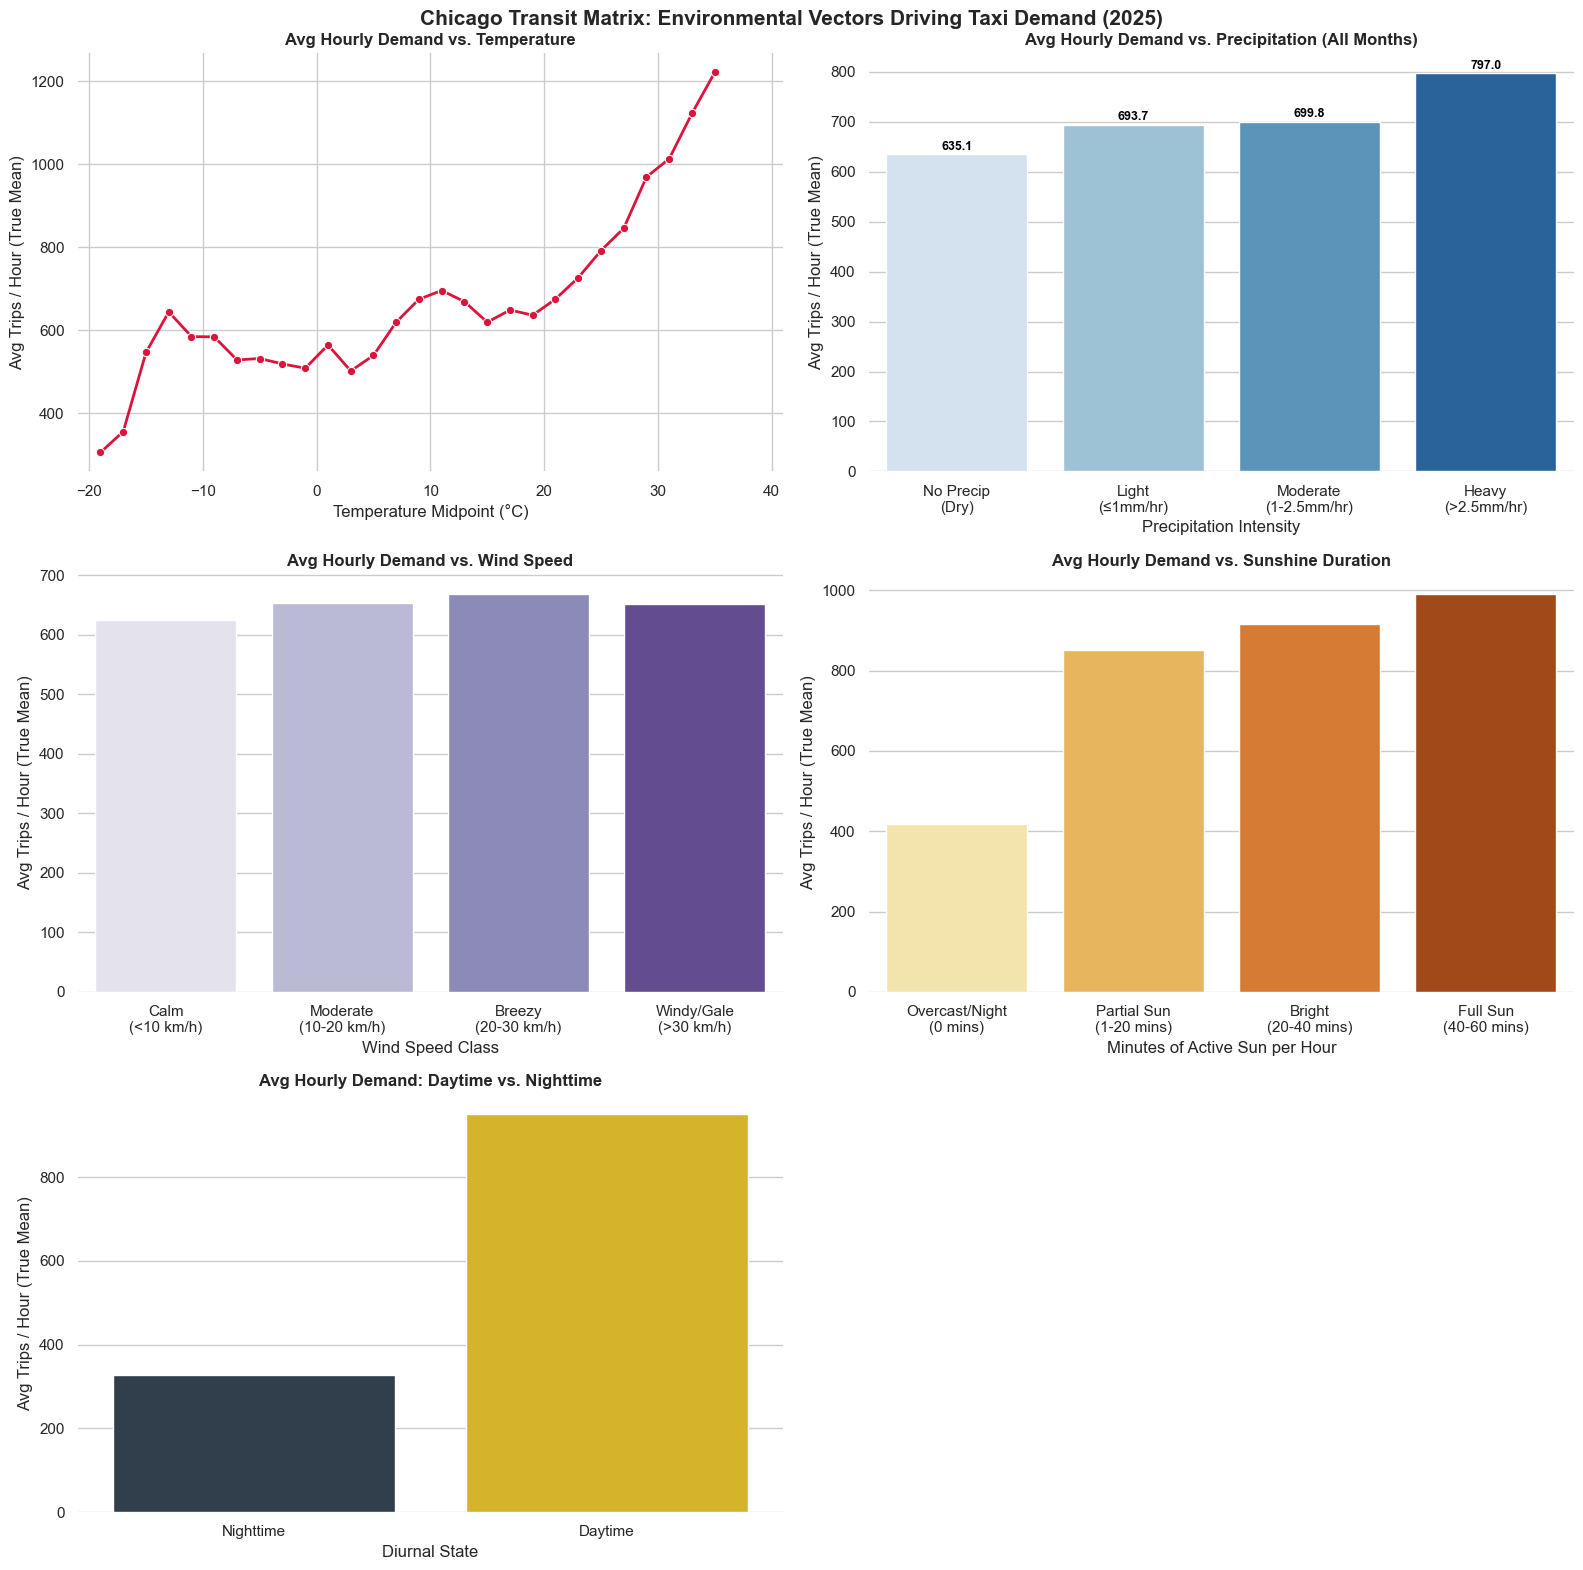

In [ ]:
# Ensure clean global styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

# =====================================================================
# PLOT 1: TEMPERATURE
# =====================================================================
# 1. Slice into 2-degree intervals
hourly_city_summary['temp_bucket'] = pd.cut(
    hourly_city_summary['temperature_2m'], 
    bins=range(-20, 41, 2)
)

# 2. Calculate true hourly averages per bucket
temp_data = hourly_city_summary.groupby('temp_bucket', observed=False)['total_trips'].mean().reset_index()

# 3. Convert interval objects to their numerical midpoints (e.g., (0, 2] becomes 1.0)
# We handle any empty NaN bins gracefully by using .dropna()
temp_data['temp_midpoint'] = temp_data['temp_bucket'].apply(lambda x: x.mid).astype(float)
temp_data = temp_data.dropna(subset=['total_trips'])

# 4. Plot using the numeric midpoint column
sns.lineplot(data=temp_data, x='temp_midpoint', y='total_trips', marker='o', color='crimson', linewidth=2, ax=axes[0])
axes[0].set_title('Avg Hourly Demand vs. Temperature', fontsize=12, weight='bold')
axes[0].set_xlabel('Temperature Midpoint (°C)')
axes[0].set_ylabel('Avg Trips / Hour (True Mean)')
axes[0].set_xlim(-21, 41)

# =====================================================================
# PLOT 2: PRECIPITATION
# =====================================================================
precip_bins = [-0.01, 0.0, 1.0, 2.5, 50.0]
precip_labels = ['No Precip\n(Dry)', 'Light\n(≤1mm/hr)', 'Moderate\n(1-2.5mm/hr)', 'Heavy\n(>2.5mm/hr)']
hourly_city_summary['precip_bucket'] = pd.cut(hourly_city_summary['precipitation'], bins=precip_bins, labels=precip_labels)
precip_data = hourly_city_summary.groupby('precip_bucket', observed=False)['total_trips'].mean().reset_index()

sns.barplot(data=precip_data, x='precip_bucket', y='total_trips', palette='Blues', ax=axes[1])
axes[1].set_title('Avg Hourly Demand vs. Precipitation (All Months)', fontsize=12, weight='bold')
axes[1].set_xlabel('Precipitation Intensity')
axes[1].set_ylabel('Avg Trips / Hour (True Mean)')

for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height() + 15),
                    ha='center', va='center', fontsize=9, color='black', weight='semibold')

# =====================================================================
# PLOT 3: WIND SPEED
# =====================================================================
wind_bins = [-0.1, 10, 20, 30, 100]
wind_labels = ['Calm\n(<10 km/h)', 'Moderate\n(10-20 km/h)', 'Breezy\n(20-30 km/h)', 'Windy/Gale\n(>30 km/h)']
hourly_city_summary['wind_bucket'] = pd.cut(hourly_city_summary['wind_speed_10m'], bins=wind_bins, labels=wind_labels)
wind_data = hourly_city_summary.groupby('wind_bucket', observed=False)['total_trips'].mean().reset_index()

sns.barplot(data=wind_data, x='wind_bucket', y='total_trips', palette='Purples', ax=axes[2])
axes[2].set_title('Avg Hourly Demand vs. Wind Speed', fontsize=12, weight='bold')
axes[2].set_xlabel('Wind Speed Class')
axes[2].set_ylabel('Avg Trips / Hour (True Mean)')

# =====================================================================
# PLOT 4: SUNSHINE DURATION
# =====================================================================
hourly_city_summary['sunshine_mins'] = hourly_city_summary['sunshine_duration'] / 60.0
sun_bins = [-0.1, 1, 20, 40, 60.1]
sun_labels = ['Overcast/Night\n(0 mins)', 'Partial Sun\n(1-20 mins)', 'Bright\n(20-40 mins)', 'Full Sun\n(40-60 mins)']
hourly_city_summary['sun_bucket'] = pd.cut(hourly_city_summary['sunshine_mins'], bins=sun_bins, labels=sun_labels)
sun_data = hourly_city_summary.groupby('sun_bucket', observed=False)['total_trips'].mean().reset_index()

sns.barplot(data=sun_data, x='sun_bucket', y='total_trips', palette='YlOrBr', ax=axes[3])
axes[3].set_title('Avg Hourly Demand vs. Sunshine Duration', fontsize=12, weight='bold')
axes[3].set_xlabel('Minutes of Active Sun per Hour')
axes[3].set_ylabel('Avg Trips / Hour (True Mean)')

# =====================================================================
# PLOT 5: DAYTIME VS. NIGHTTIME
# =====================================================================
day_data = hourly_city_summary.groupby('is_day')['total_trips'].mean().reset_index()
day_data['is_day'] = day_data['is_day'].map({0.0: 'Nighttime', 1.0: 'Daytime'})

sns.barplot(data=day_data, x='is_day', y='total_trips', palette=['#2c3e50', '#f1c40f'], ax=axes[4])
axes[4].set_title('Avg Hourly Demand: Daytime vs. Nighttime', fontsize=12, weight='bold')
axes[4].set_xlabel('Diurnal State')
axes[4].set_ylabel('Avg Trips / Hour (True Mean)')

# Hide empty subplot panel
axes[5].axis('off')

plt.suptitle('Chicago Transit Matrix: Environmental Vectors Driving Taxi Demand (2025)', fontsize=15, weight='bold', y=0.98)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [14]:
# 1. Define standard Chicago weekday rush hours (Monday=0 to Friday=4)
# We can approximate weekdays by grouping hours, but since we don't have day_of_week, 
# we will flag the core commuting hours: 7-9 AM and 4-6 PM across all days to spot the density.
rush_hours = [7, 8, 9, 16, 17, 18]
hourly_city_summary['is_rush_hour'] = hourly_city_summary['start_hour'].isin(rush_hours).astype(int)

# 2. Calculate the average trips and the PROPORTION of rush hour occurrences per bucket
temp_rush_profile = hourly_city_summary.groupby('temp_bucket', observed=False).agg(
    avg_trips=('total_trips', 'mean'),
    rush_hour_proportion=('is_rush_hour', 'mean'), # Generates the decimal percentage (0.0 to 1.0)
    total_hours_observed=('total_trips', 'count')
).reset_index()

# Convert the proportion to a clean percentage for display
temp_rush_profile['rush_hour_pct'] = temp_rush_profile['rush_hour_proportion'] * 100

print("--- RUSH HOUR PROPORTION PER TEMPERATURE BUCKET ---")
print(temp_rush_profile[['temp_bucket', 'avg_trips', 'rush_hour_pct', 'total_hours_observed']])

--- RUSH HOUR PROPORTION PER TEMPERATURE BUCKET ---
   temp_bucket    avg_trips  rush_hour_pct  total_hours_observed
0   (-20, -18]   305.192308      19.230769                    26
1   (-18, -16]   355.357143      20.000000                    70
2   (-16, -14]   546.066667      26.666667                    75
3   (-14, -12]   643.780220      31.868132                    91
4   (-12, -10]   584.276786      28.571429                   112
5    (-10, -8]   583.601449      23.188406                   138
6     (-8, -6]   528.020202      24.242424                   198
7     (-6, -4]   531.486207      25.862069                   290
8     (-4, -2]   518.451031      21.907216                   388
9      (-2, 0]   508.061425      24.570025                   407
10      (0, 2]   564.047493      27.440633                   379
11      (2, 4]   501.537383      23.364486                   428
12      (4, 6]   539.010225      24.539877                   489
13      (6, 8]   619.260700      23.15

/var/folders/gs/gk7qm_b92t308pxzdf4h3y0r0000gn/T/ipykernel_2084/2717800057.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


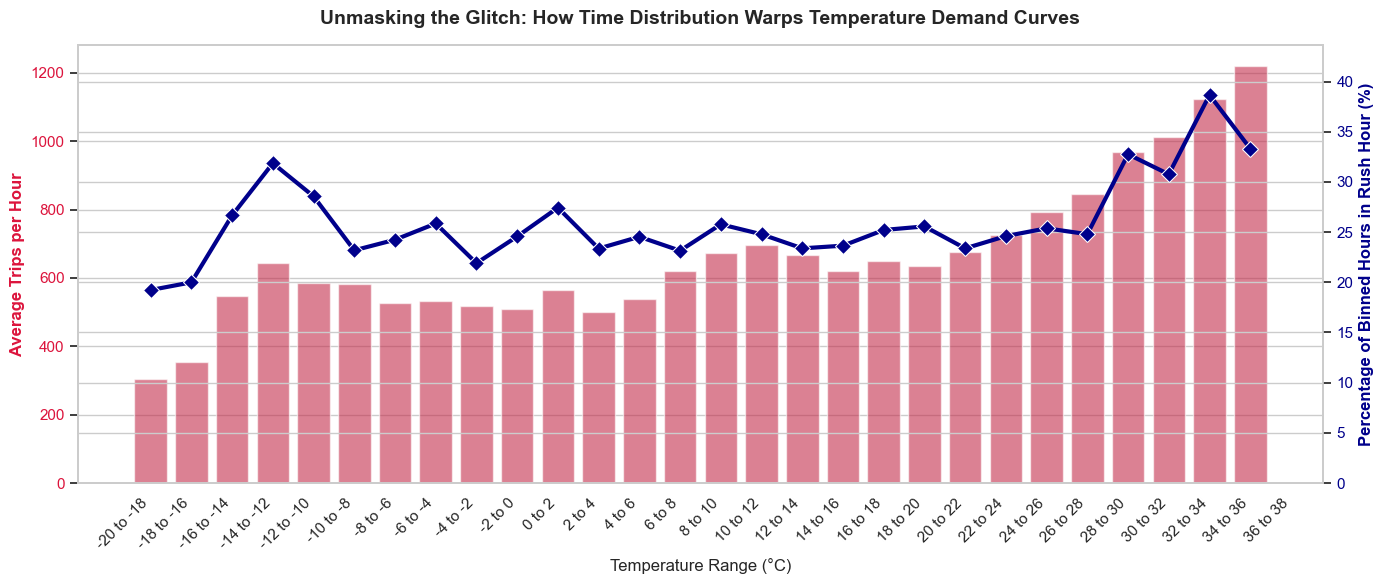

In [ ]:
# 1. Extract the numerical midpoint so sns.lineplot can calculate positions geometrically
temp_rush_profile['temp_midpoint'] = temp_rush_profile['temp_bucket'].apply(lambda x: x.mid).astype(float)

# 2. Create a clean string label column for the bar axis display (e.g., "0 to 2")
temp_rush_profile['temp_label'] = temp_rush_profile['temp_bucket'].apply(lambda x: f"{int(x.left)} to {int(x.right)}")

# Filter out bins that have 0 observations to keep the chart clean
plot_profile = temp_rush_profile[temp_rush_profile['total_hours_observed'] > 0].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# 1. Plot Average Taxi Demand (Bars - Crimson) using the clean text label
sns.barplot(
    data=plot_profile, 
    x='temp_label', 
    y='avg_trips', 
    color='crimson', 
    alpha=0.6, 
    ax=ax1
)
ax1.set_ylabel('Average Trips per Hour', color='crimson', fontsize=12, weight='bold')
ax1.set_xlabel('Temperature Range (°C)', fontsize=12)
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# 2. Create twin axis to overlay Rush Hour Percentage (Line - Navy)
ax2 = ax1.twinx()

# 3. Map the line to the EXACT SAME x-categorical categories by leveraging 
# the index positions of the categories (0, 1, 2...) so it aligns perfectly with the bars.
sns.lineplot(
    x=range(len(plot_profile)), 
    y=plot_profile['rush_hour_pct'], 
    color='darkblue', 
    marker='D', 
    linewidth=3, 
    markersize=8,
    ax=ax2
)
ax2.set_ylabel('Percentage of Binned Hours in Rush Hour (%)', color='darkblue', fontsize=12, weight='bold')
ax2.tick_params(axis='y', labelcolor='darkblue')

# Fix limits to give line breathing room
ax2.set_ylim(0, plot_profile['rush_hour_pct'].max() + 5)

plt.title('Unmasking the Glitch: How Time Distribution Warps Temperature Demand Curves', fontsize=14, pad=15, weight='bold')
fig.tight_layout()
plt.show()

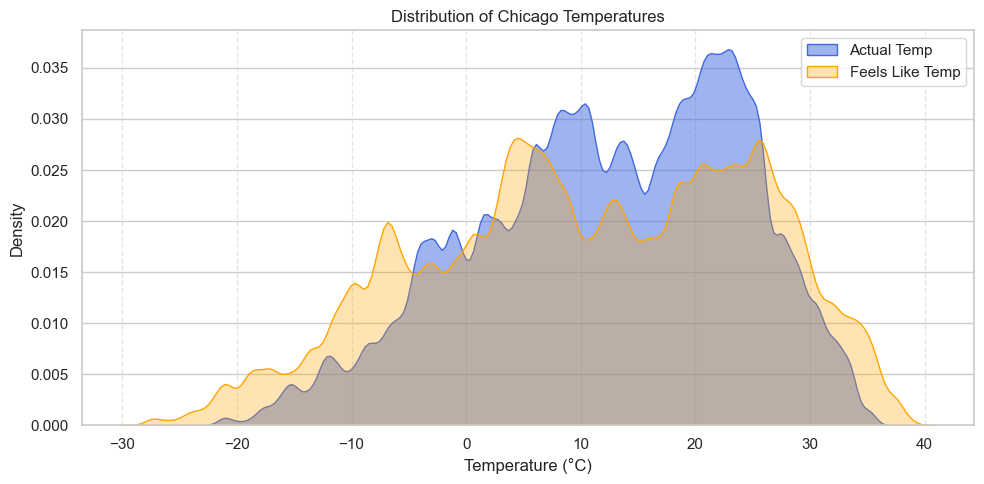

In [18]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data['temperature_2m'], label='Actual Temp', fill=True, color='royalblue', alpha=0.5)
sns.kdeplot(data['apparent_temperature'], label='Feels Like Temp', fill=True, color='orange', alpha=0.3)

plt.title('Distribution of Chicago Temperatures')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [19]:
# 1. Calculate the temperature difference vector
# Positive = It feels COLDER than the actual air temperature (e.g., due to wind chill)
# Negative = It feels HOTTER than the actual air temperature (e.g., due to humidity)
hourly_city_summary['actual_vs_felt_temperature'] = (
    hourly_city_summary['temperature_2m'] - hourly_city_summary['apparent_temperature']
)

# 2. Create a categorical flag to separate positive and negative states
# We filter out exactly 0.0 to keep the contrast sharp between the two states
def categorize_gap(val):
    if val > 0:
        return 'Feels Colder\n(Actual > Apparent)'
    elif val < 0:
        return 'Feels Hotter\n(Actual < Apparent)'
    else:
        return 'Feels Exact\n(Equal)'

hourly_city_summary['thermal_state'] = hourly_city_summary['actual_vs_felt_temperature'].apply(categorize_gap)

print("Column 'actual_vs_felt_temperature' successfully engineered!")
print(hourly_city_summary[['temperature_2m', 'apparent_temperature', 'actual_vs_felt_temperature', 'thermal_state']].head())

Column 'actual_vs_felt_temperature' successfully engineered!
   temperature_2m  apparent_temperature  actual_vs_felt_temperature  \
0            0.75             -3.466830                    4.216830   
1            0.65             -3.722961                    4.372961   
2            0.20             -4.808792                    5.008792   
3           -0.25             -5.260139                    5.010139   
4           -0.50             -5.667282                    5.167282   

                       thermal_state  
0  Feels Colder\n(Actual > Apparent)  
1  Feels Colder\n(Actual > Apparent)  
2  Feels Colder\n(Actual > Apparent)  
3  Feels Colder\n(Actual > Apparent)  
4  Feels Colder\n(Actual > Apparent)  


/var/folders/gs/gk7qm_b92t308pxzdf4h3y0r0000gn/T/ipykernel_2084/946862609.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


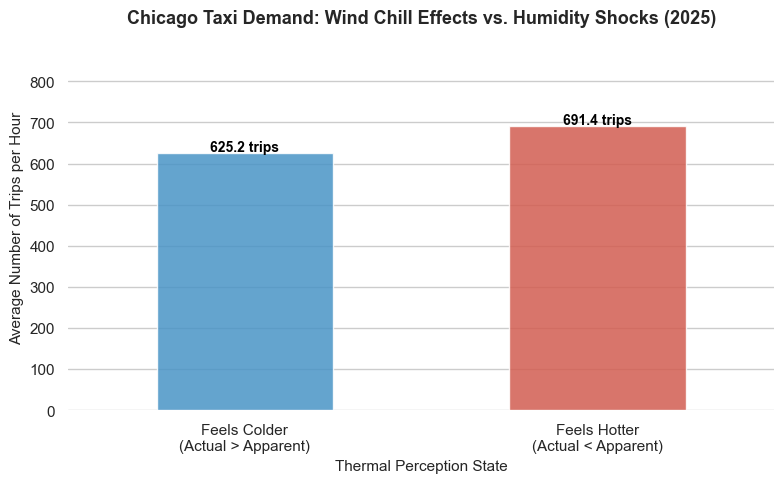

In [20]:
# 1. Filter out the 'Feels Exact' rows so we focus purely on Positive vs Negative states
plot_df = hourly_city_summary[hourly_city_summary['thermal_state'] != 'Feels Exact\n(Equal)']

# 2. Calculate true hourly averages for both states
thermal_profile = plot_df.groupby('thermal_state')['total_trips'].mean().reset_index()

# 3. Create the bar chart
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Crimson for cold-deficit shocks, Orange-Red for heat-humidity shocks
ax = sns.barplot(
    data=thermal_profile, 
    x='thermal_state', 
    y='total_trips', 
    palette=['#3498db', '#e74c3c'],  # Blue for biting wind chill, Red for heavy humidity
    alpha=0.85,
    width=0.5
)

# 4. Customizing titles and formatting labels
plt.title('Chicago Taxi Demand: Wind Chill Effects vs. Humidity Shocks (2025)', fontsize=13, pad=15, weight='bold')
plt.xlabel('Thermal Perception State', fontsize=11)
plt.ylabel('Average Number of Trips per Hour', fontsize=11)

# Add exact average labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f} trips", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 15), 
                ha='center', va='center', fontsize=10, color='black', weight='semibold')

# Add minor breathing room on the y-axis
plt.ylim(0, thermal_profile['total_trips'].max() + 200)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()